# Import Dataset

We have 2 datasets of Bike Sharing:
- daily dataset, and
- hourly dataset

There is a subtle different of these two datasets. Hourly dataset has one addition column, called **hr** that representing hour. The rest of the columns are the same for both datasets.

In [30]:
import pandas as pd

df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')

## Daily Dataset

In [31]:
# preview of the dataset
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [32]:
# statistic summary of the dataset
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [34]:
# dataset structure
df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


## Handling Missing Values

In [35]:
df_missing_values = {
    'Column': df_day.columns,
    'Number of Missing Values': df_day.isna().sum(),
    'Missing Values (%)': df_day.isna().sum()*100/len(df_day)
}

df_missing_values = pd.DataFrame(df_missing_values)
df_missing_values

,Column,Number of Missing Values,Missing Values (%)
instant,instant,0,0.0
dteday,dteday,0,0.0
season,season,0,0.0
yr,yr,0,0.0
mnth,mnth,0,0.0
holiday,holiday,0,0.0
weekday,weekday,0,0.0
workingday,workingday,0,0.0
weathersit,weathersit,0,0.0
temp,temp,0,0.0


Pretty good :) There are no missing values here. We can move on to the next step.

## Handling Duplicate Data

In [36]:
duplicate = df_day.duplicated()
df_day[duplicate]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


Nice one :) There is no duplicate data here. One more blessing from God LOL. Okay, let's move on to the next step.

## Splitting Data

In [37]:
from sklearn.model_selection import train_test_split

df_day_train, df_day_test = train_test_split(df_day,test_size=0.2, random_state=42)

In [38]:
df_day_train.info()

<class 'pandas.DataFrame'>
Index: 584 entries, 682 to 102
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     584 non-null    int64  
 1   dteday      584 non-null    str    
 2   season      584 non-null    int64  
 3   yr          584 non-null    int64  
 4   mnth        584 non-null    int64  
 5   holiday     584 non-null    int64  
 6   weekday     584 non-null    int64  
 7   workingday  584 non-null    int64  
 8   weathersit  584 non-null    int64  
 9   temp        584 non-null    float64
 10  atemp       584 non-null    float64
 11  hum         584 non-null    float64
 12  windspeed   584 non-null    float64
 13  casual      584 non-null    int64  
 14  registered  584 non-null    int64  
 15  cnt         584 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 77.6 KB


In [39]:
df_day_test.info()

<class 'pandas.DataFrame'>
Index: 147 entries, 703 to 135
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     147 non-null    int64  
 1   dteday      147 non-null    str    
 2   season      147 non-null    int64  
 3   yr          147 non-null    int64  
 4   mnth        147 non-null    int64  
 5   holiday     147 non-null    int64  
 6   weekday     147 non-null    int64  
 7   workingday  147 non-null    int64  
 8   weathersit  147 non-null    int64  
 9   temp        147 non-null    float64
 10  atemp       147 non-null    float64
 11  hum         147 non-null    float64
 12  windspeed   147 non-null    float64
 13  casual      147 non-null    int64  
 14  registered  147 non-null    int64  
 15  cnt         147 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 19.5 KB


## Handling Outliers Data

In [40]:
# import all library that we needed
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Training Data

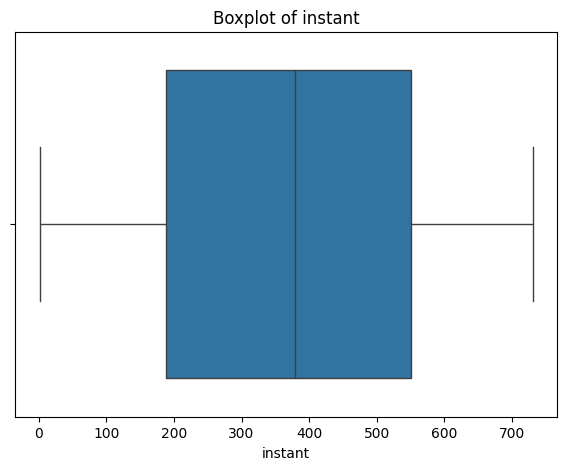

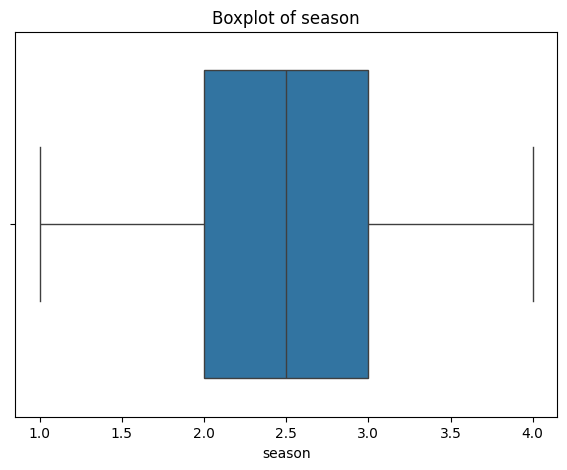

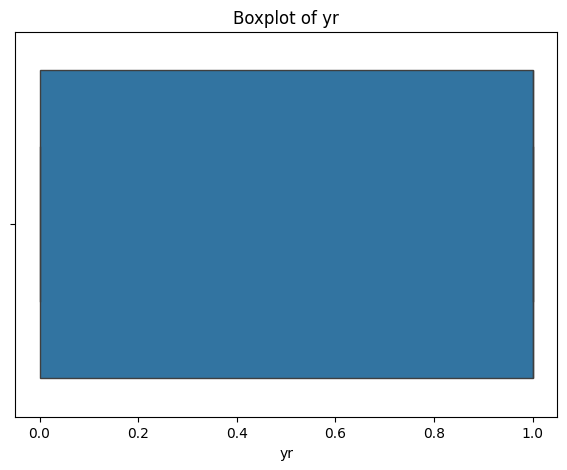

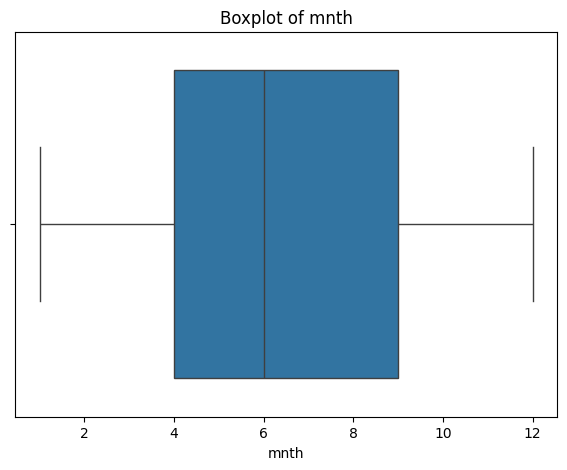

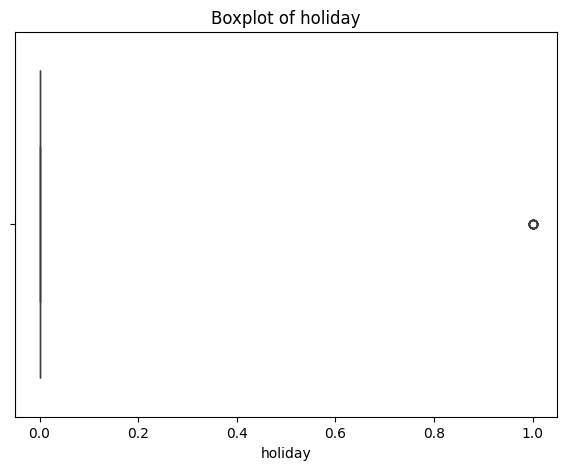

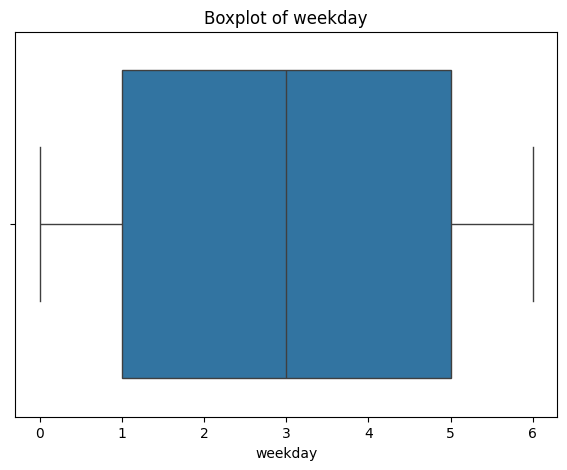

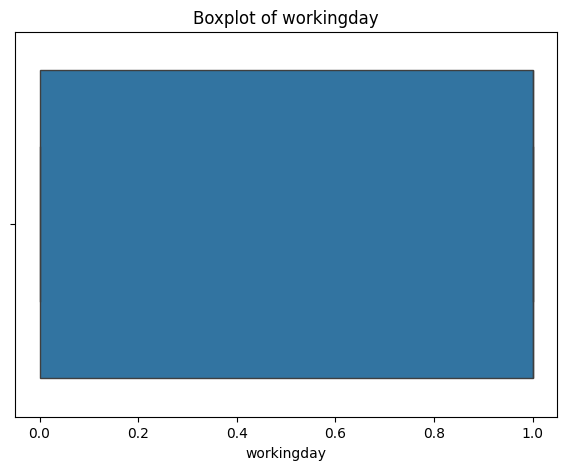

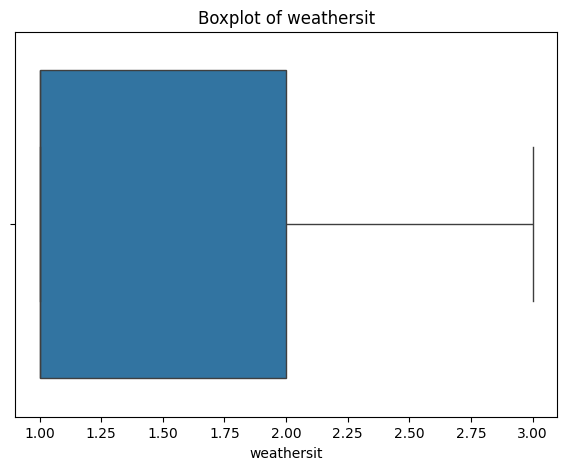

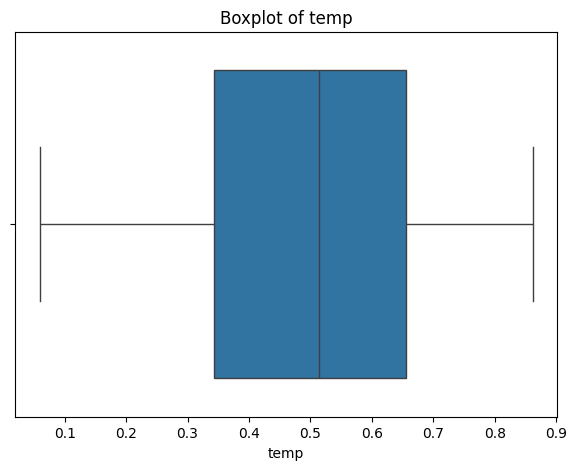

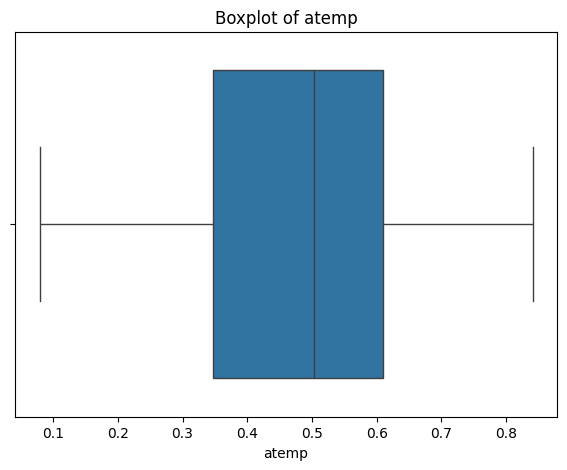

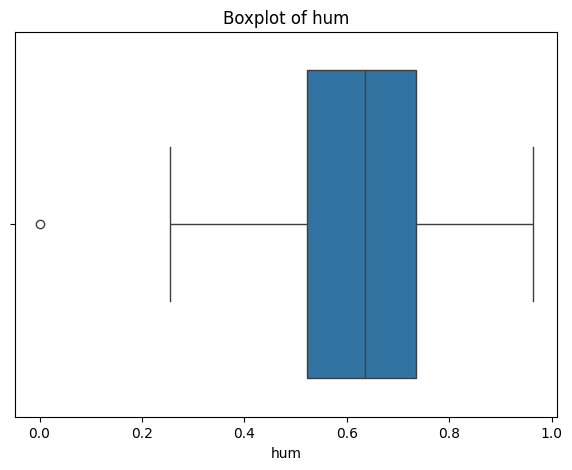

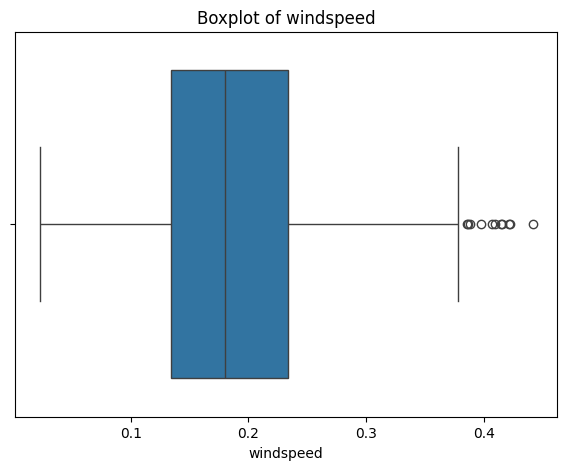

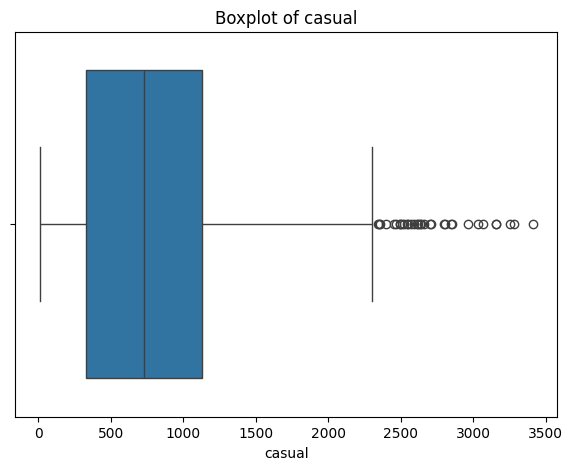

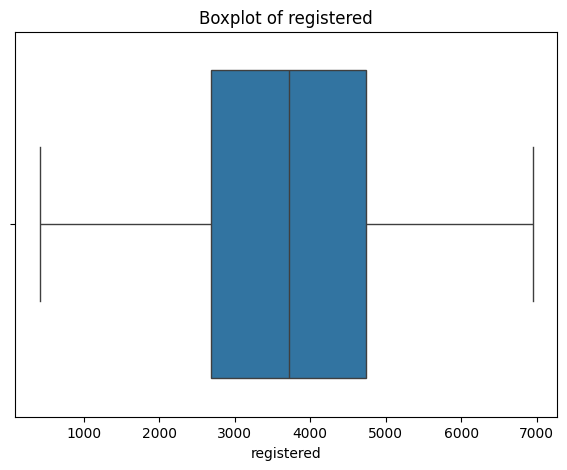

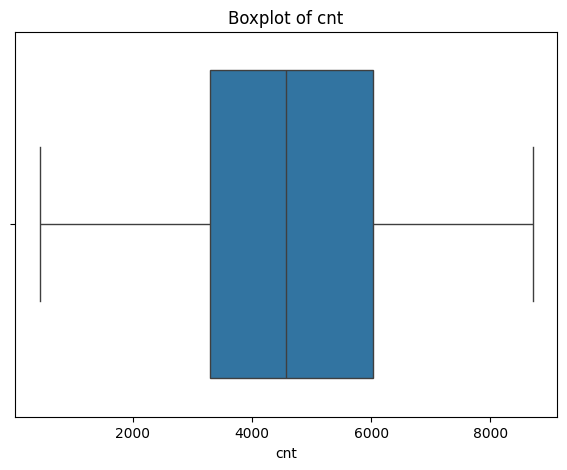

In [41]:
# visualize/identify the outliers using boxplot diagram
for feature in df_day_train.drop(columns=['dteday']).columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=df_day_train[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

There are 3 columns that has outliers, they are *holiday*, *hum*, *windspeed*, and *casual*. For holiday column, the outliers are not valid. The records in the holiday column are only have 2 value uniquely, one and zero. The one values are categorized into outliers and this does not make any sense. So, we can ignore these outliers for holiday column.

In [42]:
df_no_outlier = df_day_train.drop(columns=['dteday','holiday'])
Q1 = df_no_outlier.quantile(0.25)
Q3 = df_no_outlier.quantile(0.75)
IQR = Q3 - Q1

In [43]:
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

condition = ~((df_no_outlier<lower)|(df_no_outlier>upper)).any(axis=1)
df_day_train_after = df_day_train.loc[condition]

In [46]:
upper

instant        1094.625000
season            4.500000
yr                2.500000
mnth             16.500000
weekday          11.000000
workingday        2.500000
weathersit        3.500000
temp              1.125104
atemp             1.003761
hum               1.052552
windspeed         0.383496
casual         2336.750000
registered     7816.750000
cnt           10144.000000
dtype: float64

In [44]:
df_day_train_after.info()

<class 'pandas.DataFrame'>
Index: 539 entries, 682 to 102
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     539 non-null    int64  
 1   dteday      539 non-null    str    
 2   season      539 non-null    int64  
 3   yr          539 non-null    int64  
 4   mnth        539 non-null    int64  
 5   holiday     539 non-null    int64  
 6   weekday     539 non-null    int64  
 7   workingday  539 non-null    int64  
 8   weathersit  539 non-null    int64  
 9   temp        539 non-null    float64
 10  atemp       539 non-null    float64
 11  hum         539 non-null    float64
 12  windspeed   539 non-null    float64
 13  casual      539 non-null    int64  
 14  registered  539 non-null    int64  
 15  cnt         539 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 71.6 KB


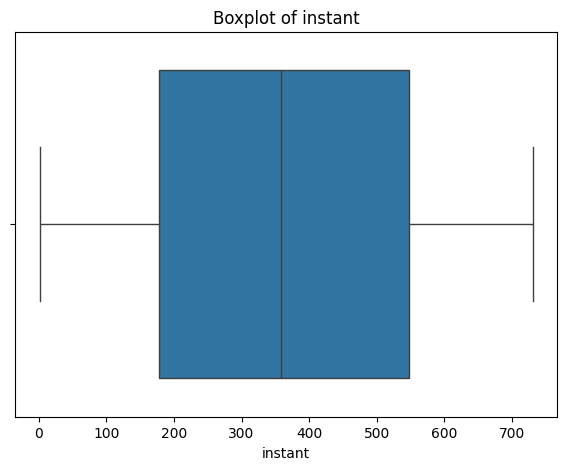

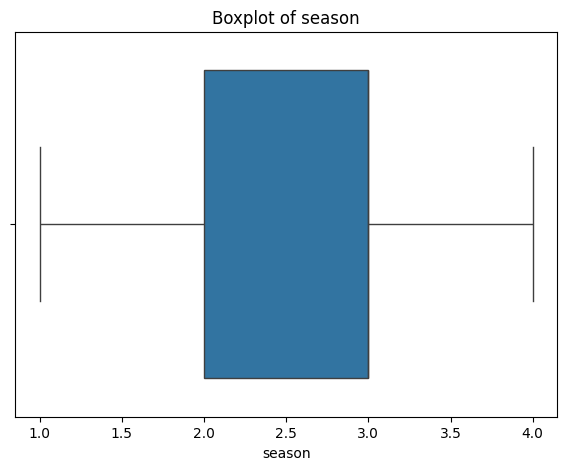

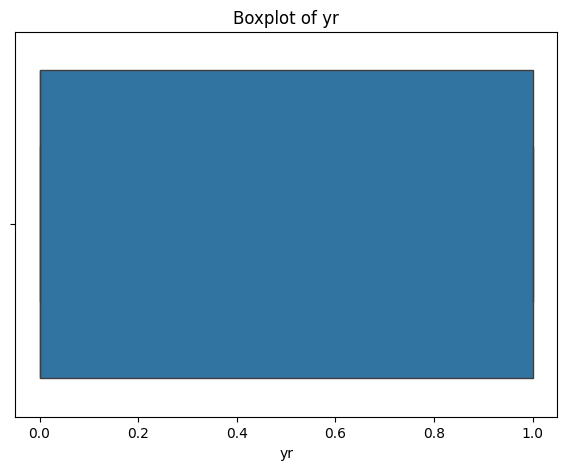

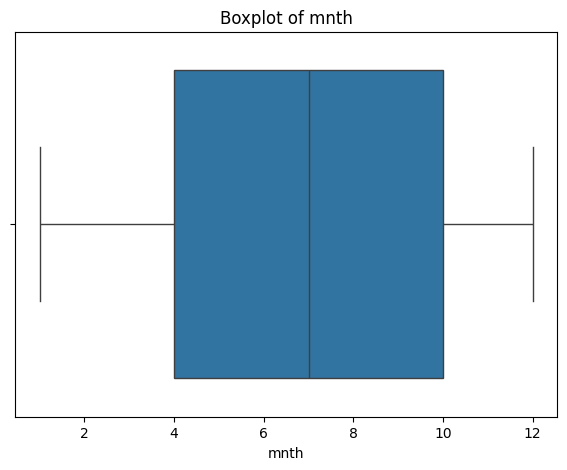

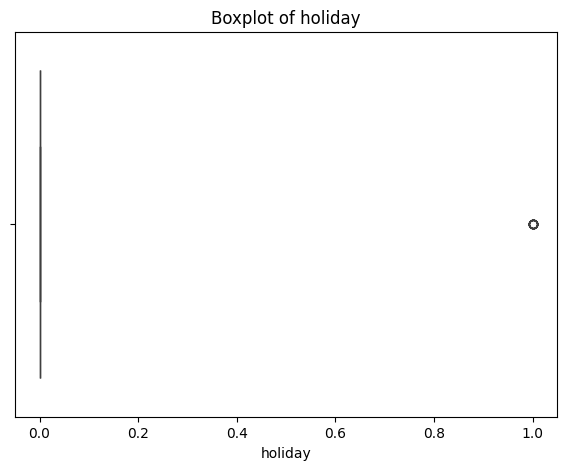

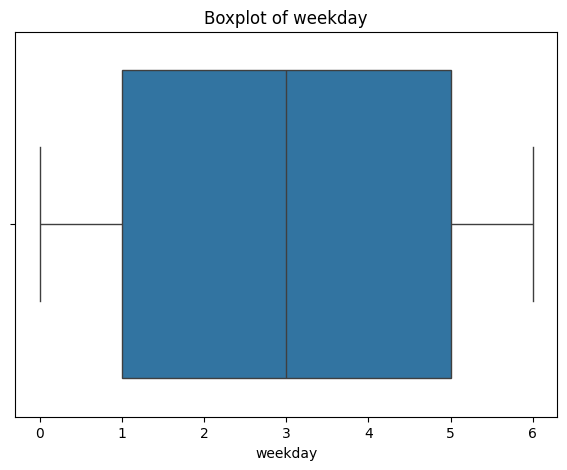

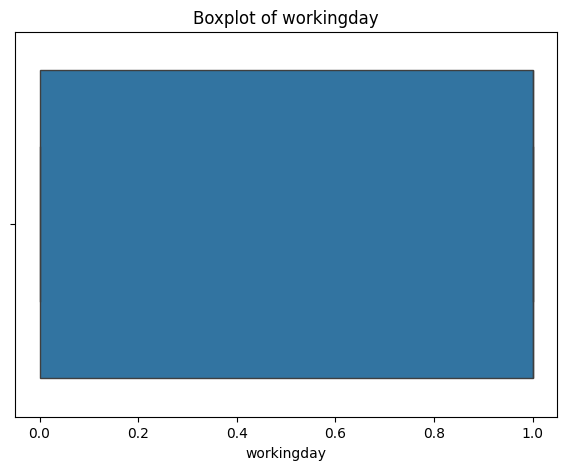

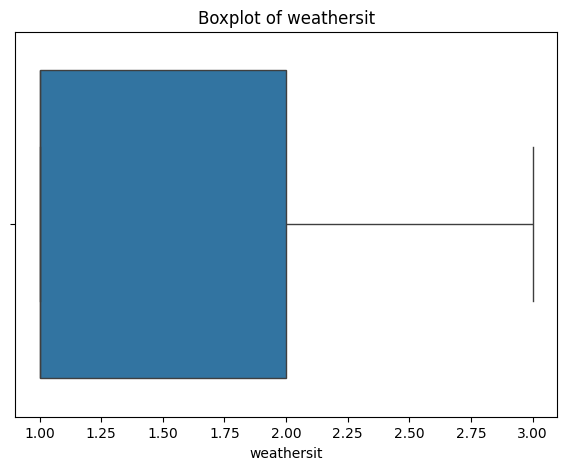

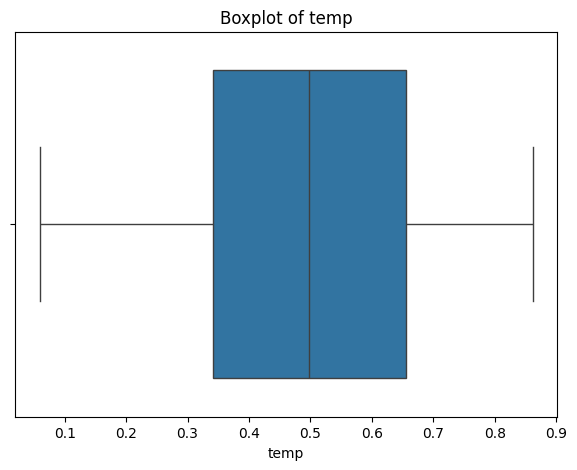

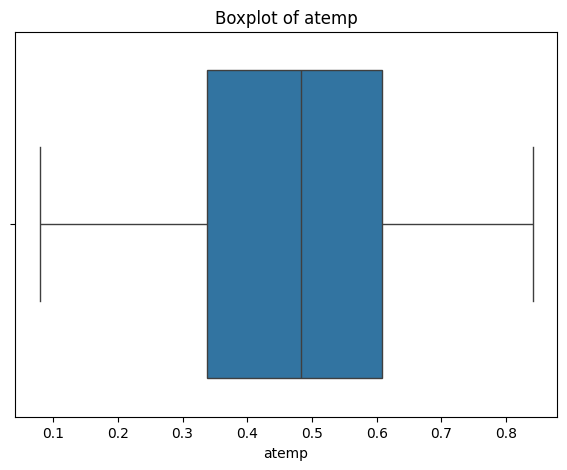

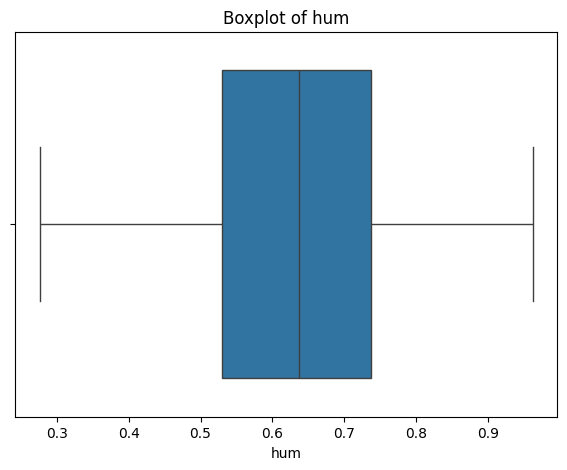

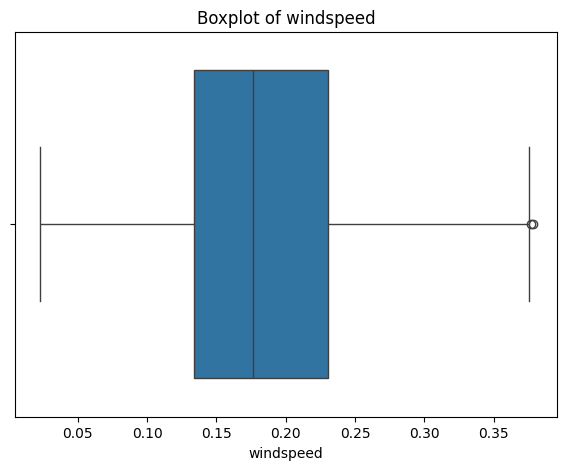

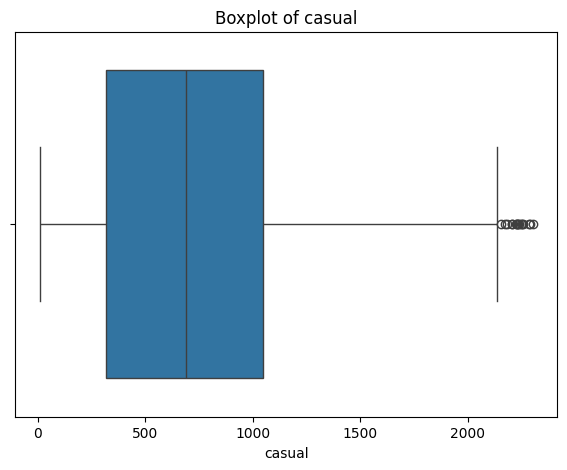

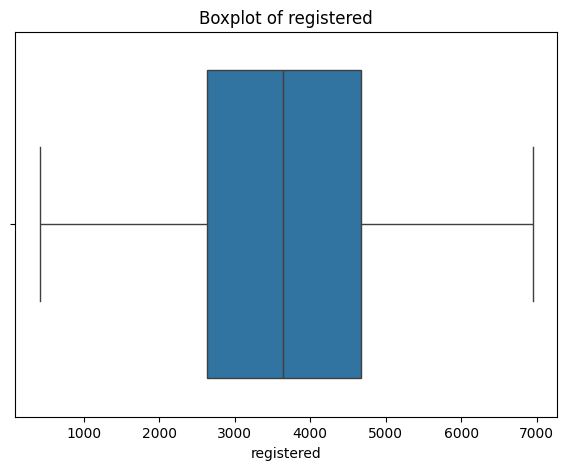

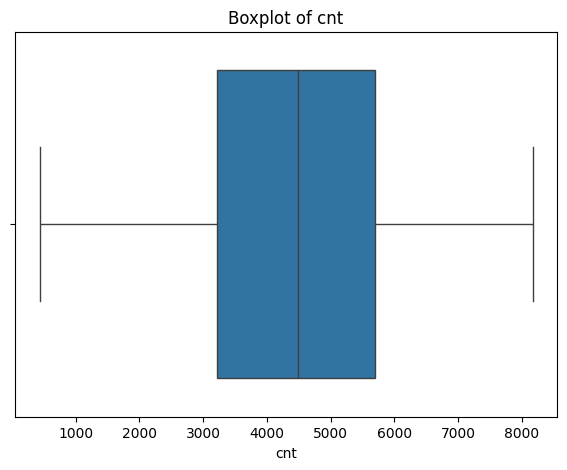

In [45]:
# visualize/identify the outliers using boxplot diagram
for feature in df_day_train_after.drop(columns=['dteday']).columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=df_day_train_after[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

### Test Data

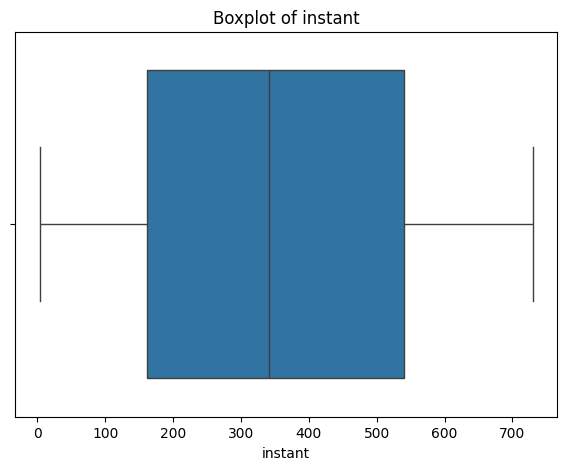

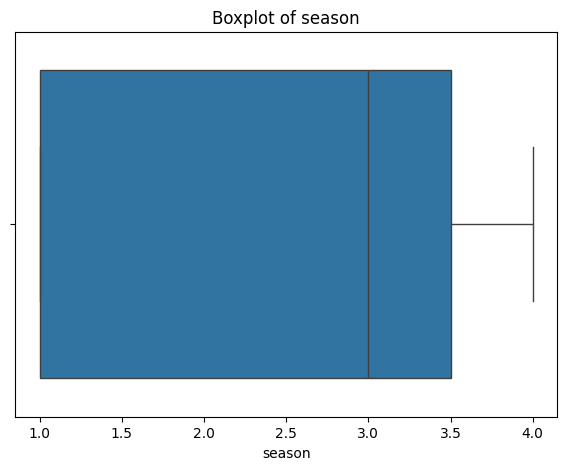

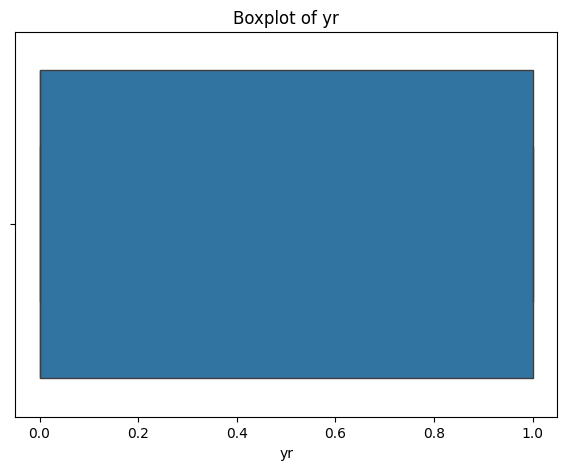

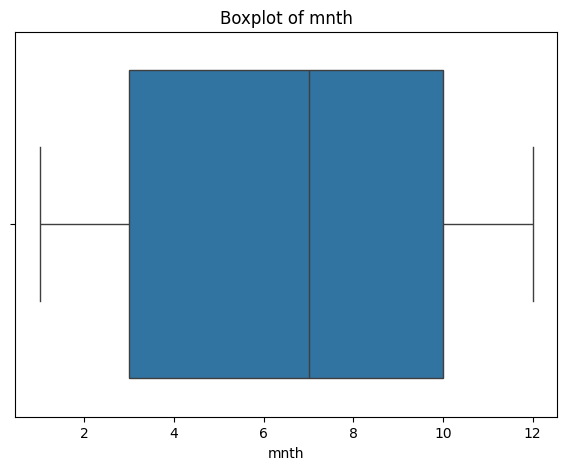

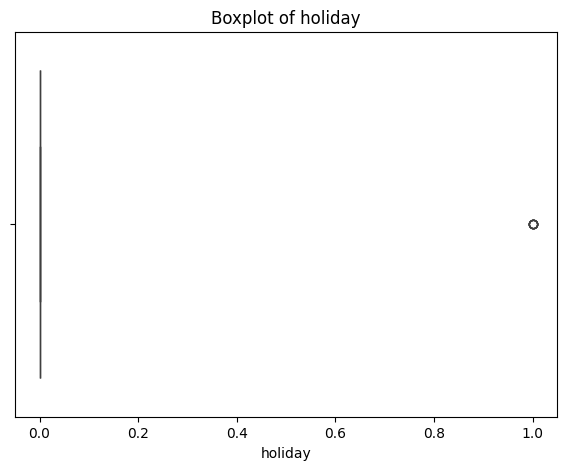

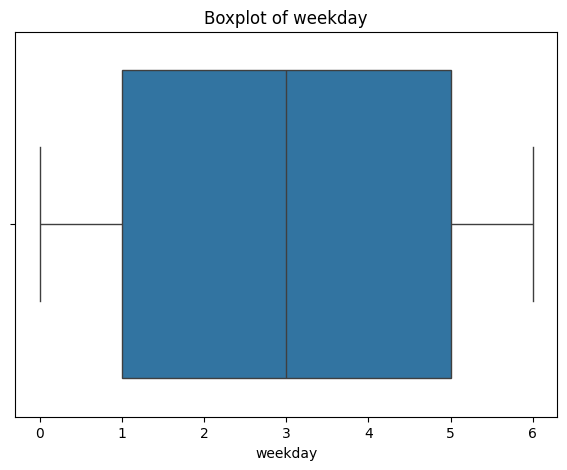

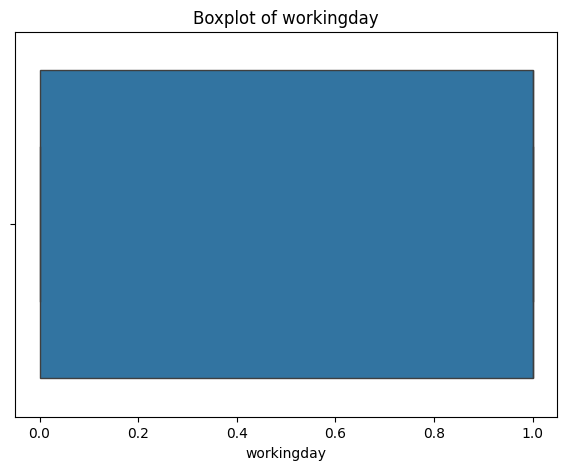

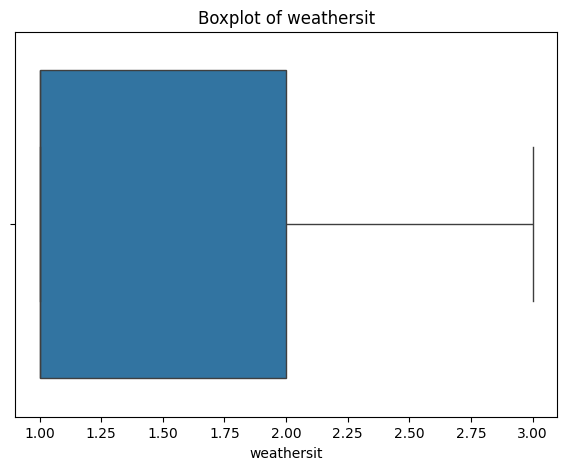

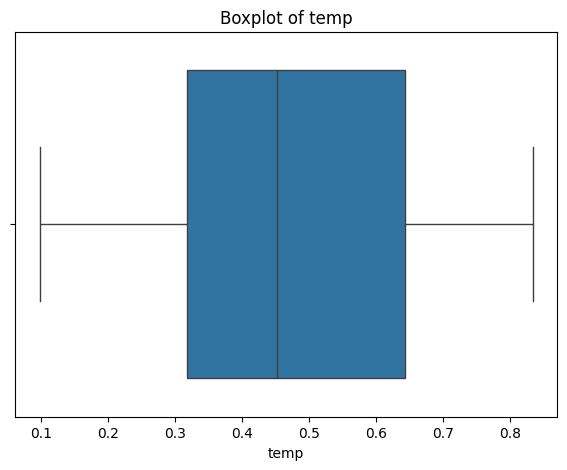

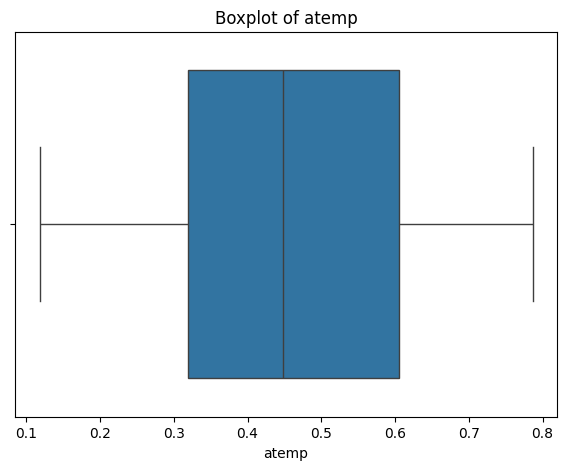

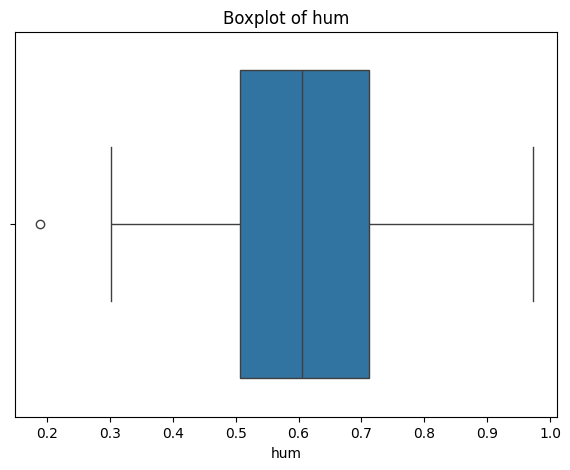

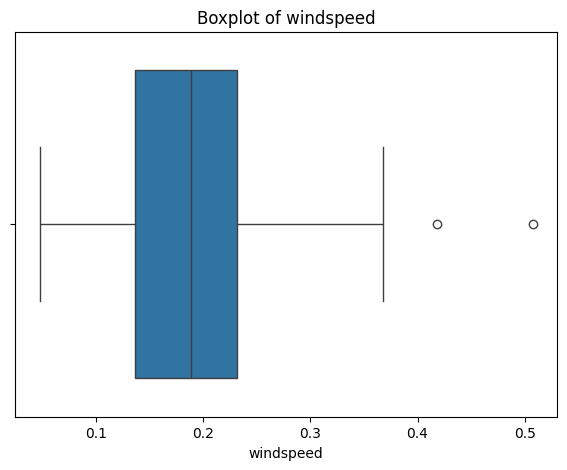

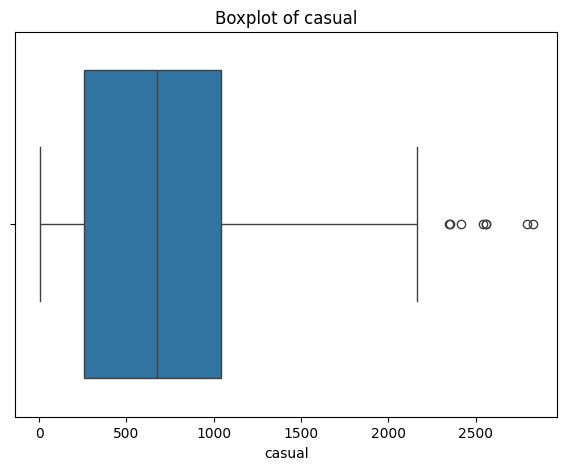

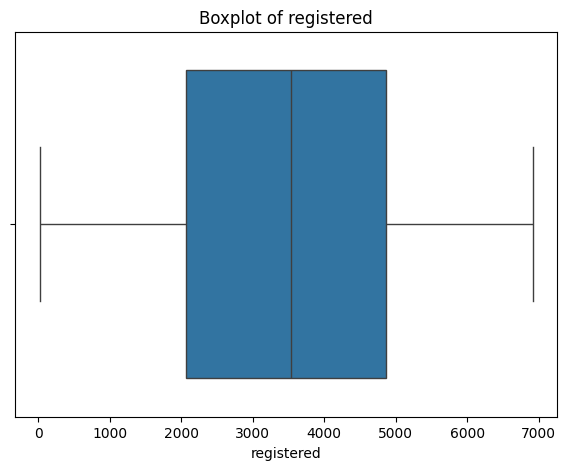

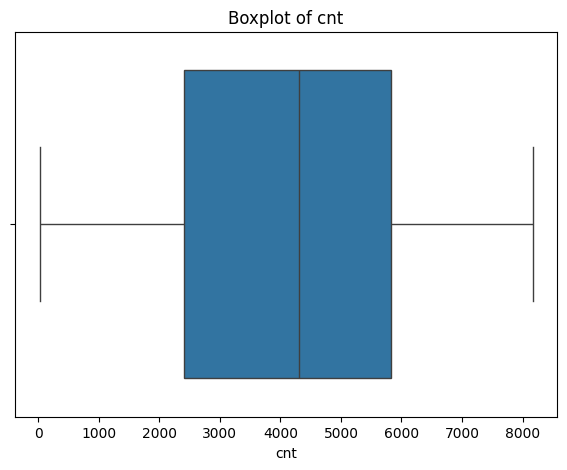

In [52]:
# visualize/identify the outliers using boxplot diagram
for feature in df_day_test.drop(columns=['dteday']).columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=df_day_test[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

There are 3 columns that has outliers, they are *holiday*, *hum*, *windspeed*, and *casual*. For holiday column, the outliers are not valid. The records in the holiday column are only have 2 value uniquely, one and zero. The one values are categorized into outliers and this does not make any sense. So, we can ignore these outliers for holiday column.

In [53]:
df_no_outlier = df_day_test.drop(columns=['dteday','holiday'])

In [55]:
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

condition = ~((df_no_outlier<lower)|(df_no_outlier>upper)).any(axis=1)
df_day_test_after = df_day_test.loc[condition]

In [56]:
df_day_test_after.info()

<class 'pandas.DataFrame'>
Index: 137 entries, 703 to 135
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     137 non-null    int64  
 1   dteday      137 non-null    str    
 2   season      137 non-null    int64  
 3   yr          137 non-null    int64  
 4   mnth        137 non-null    int64  
 5   holiday     137 non-null    int64  
 6   weekday     137 non-null    int64  
 7   workingday  137 non-null    int64  
 8   weathersit  137 non-null    int64  
 9   temp        137 non-null    float64
 10  atemp       137 non-null    float64
 11  hum         137 non-null    float64
 12  windspeed   137 non-null    float64
 13  casual      137 non-null    int64  
 14  registered  137 non-null    int64  
 15  cnt         137 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 18.2 KB


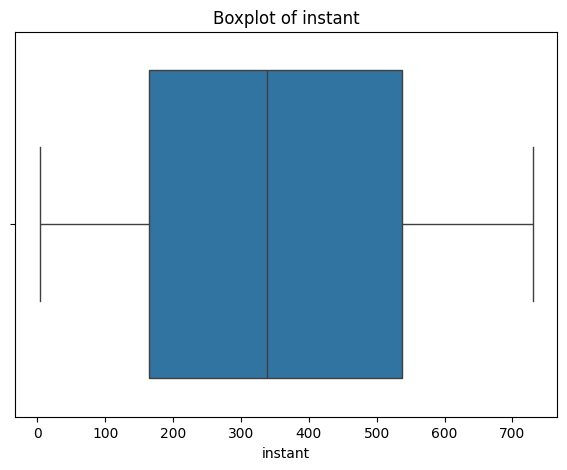

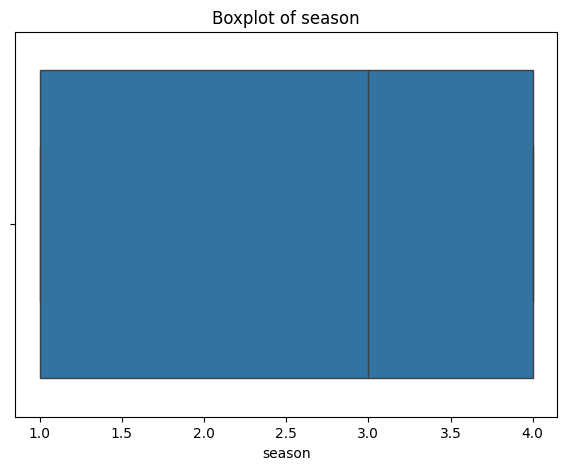

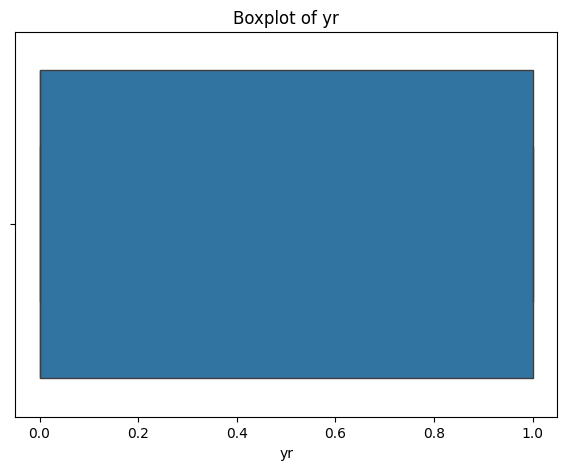

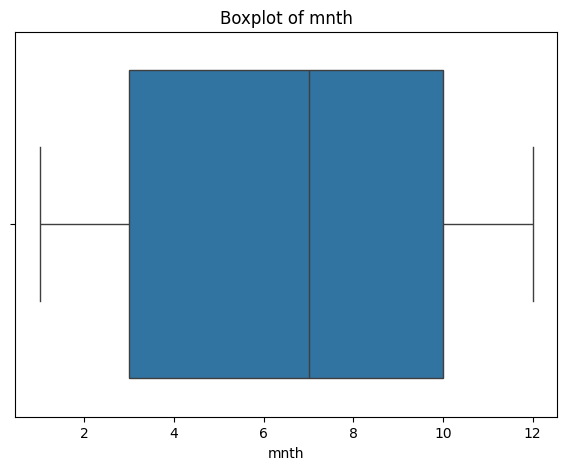

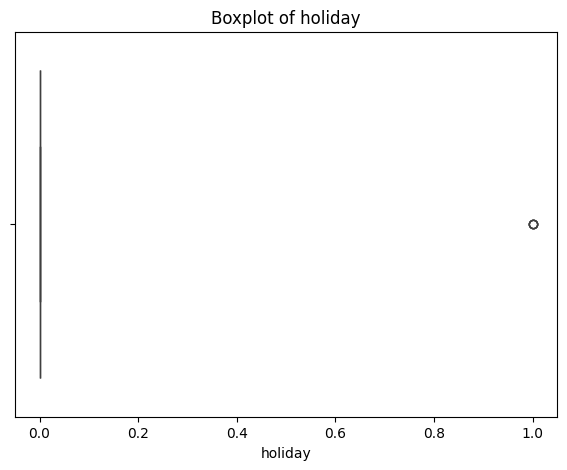

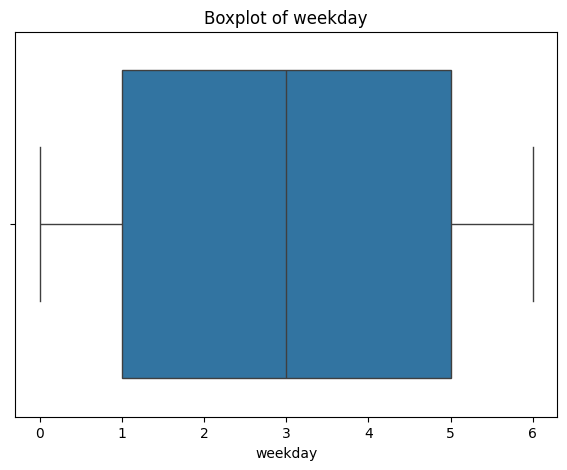

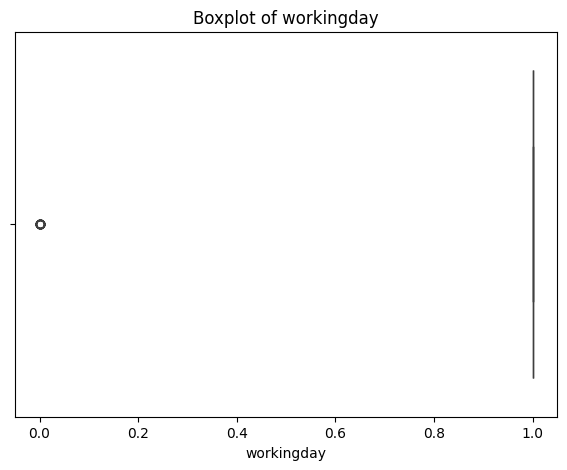

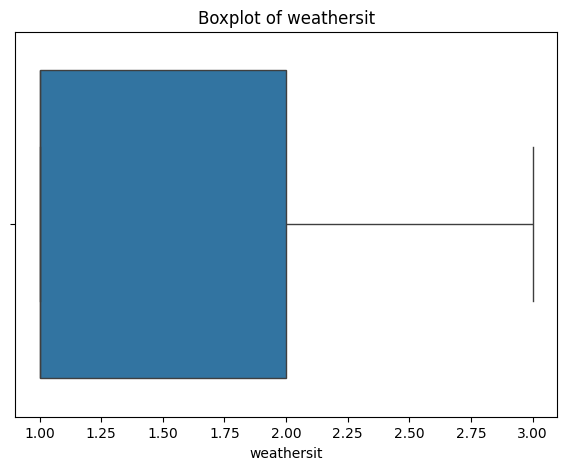

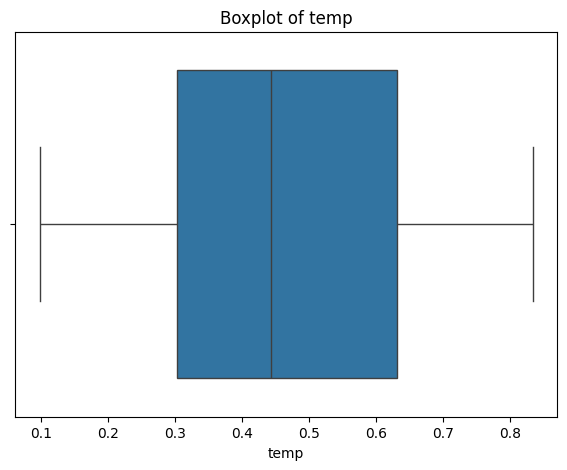

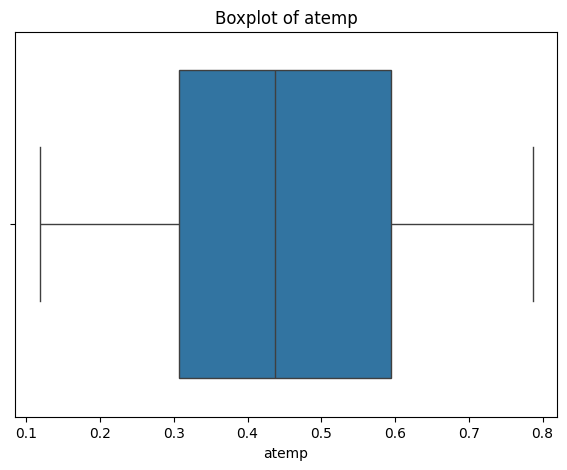

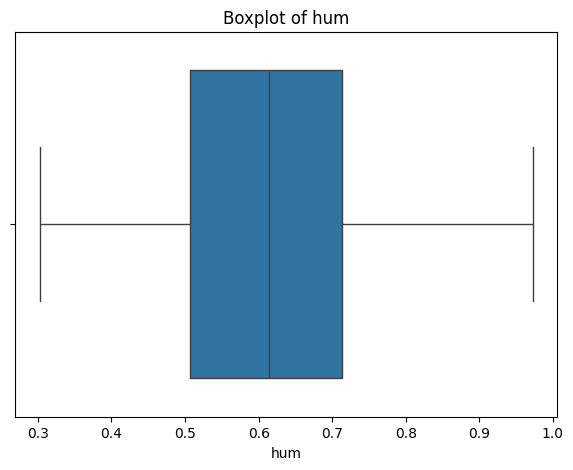

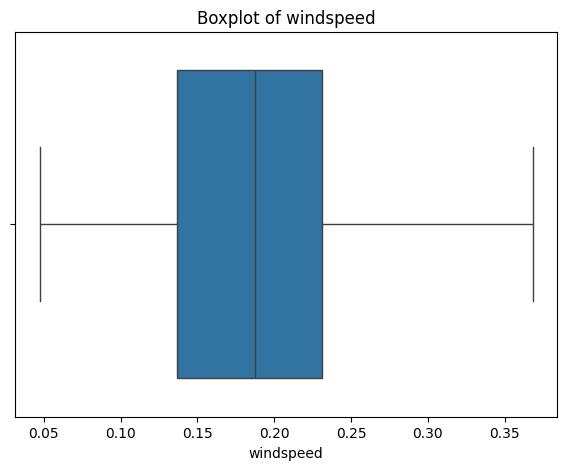

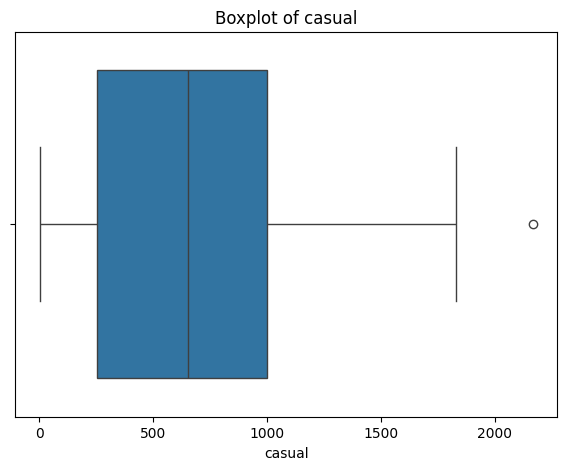

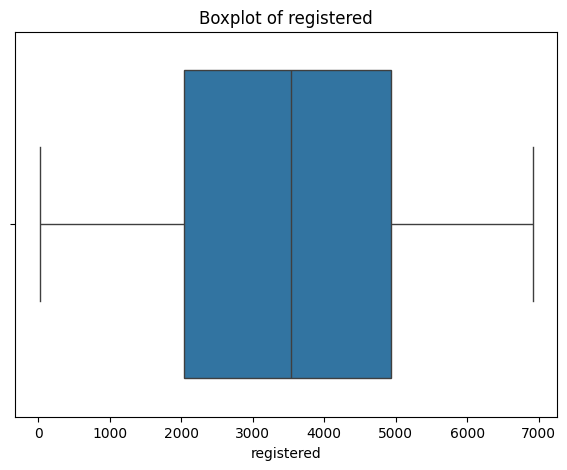

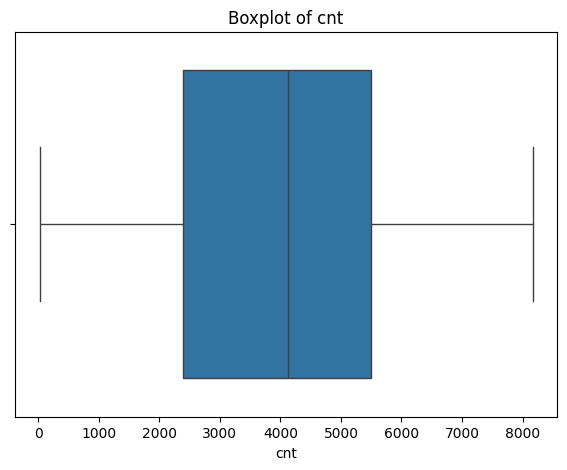

In [57]:
# visualize/identify the outliers using boxplot diagram
for feature in df_day_test_after.drop(columns=['dteday']).columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=df_day_test_after[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()